In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [ ]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)

In [ ]:
df

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0
...,...,...,...,...,...
886,2,male,27.0,13.0000,0
887,1,female,19.0,30.0000,1
888,3,female,NaN,23.4500,0
889,1,male,26.0,30.0000,1


In [ ]:
data = pd.get_dummies(df)
data.head(3)

,Pclass,Age,Fare,Survived,Sex_female,Sex_male
0,3,22.0,7.2500,0,False,True
1,1,38.0,71.2833,1,True,False
2,3,26.0,7.9250,1,True,False


In [ ]:
data.drop(['Sex_female'],axis='columns',inplace=True)
data.head(3)

,Pclass,Age,Fare,Survived,Sex_male
0,3,22.0,7.2500,0,True
1,1,38.0,71.2833,1,False
2,3,26.0,7.9250,1,False


In [ ]:
data.Age = data.Age.fillna(data.Age.median())
data.head(10)

,Pclass,Age,Fare,Survived,Sex_male
0,3,22.0,7.2500,0,True
1,1,38.0,71.2833,1,False
2,3,26.0,7.9250,1,False
3,1,35.0,53.1000,1,False
4,3,35.0,8.0500,0,True
5,3,28.0,8.4583,0,True
6,1,54.0,51.8625,0,True
7,3,2.0,21.0750,0,True
8,3,27.0,11.1333,1,False
9,2,14.0,30.0708,1,False


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
 3   Survived  891 non-null    int64  
 4   Sex_male  891 non-null    bool   
dtypes: bool(1), float64(2), int64(2)
memory usage: 28.8 KB


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = data.drop(['Survived'], axis='columns')
y = data.Survived

In [ ]:
X

,Pclass,Age,Fare,Sex_male
0,3,22.0,7.2500,True
1,1,38.0,71.2833,False
2,3,26.0,7.9250,False
3,1,35.0,53.1000,False
4,3,35.0,8.0500,True
...,...,...,...,...
886,2,27.0,13.0000,True
887,1,19.0,30.0000,False
888,3,28.0,23.4500,False
889,1,26.0,30.0000,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
len(X_train)

712

In [ ]:
len(X_test)

179

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
knn.score(X_test, y_test)

0.6871508379888268

In [ ]:
knn.predict([[3,50,7,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[94, 12],
       [44, 29]])

Text(58.222222222222214, 0.5, 'Truth')

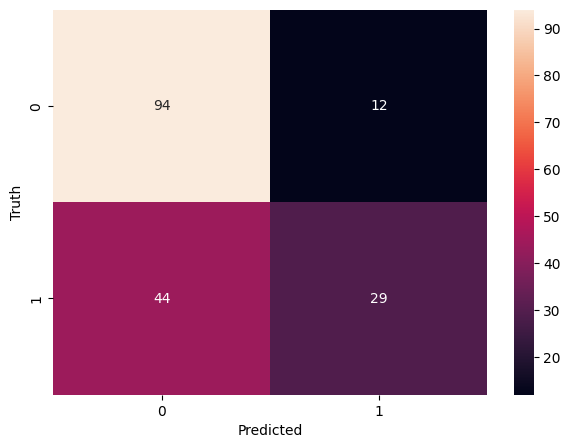

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')